<a href="https://colab.research.google.com/github/Soumit2k05/MP-1-7th-Sem-Soumit-Subhasish-Roshan-Rajaram/blob/main/03b_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


 Mount Drive and Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ UPDATE THIS PATH to match your shared Drive folder
DATA_PATH = '/content/drive/MyDrive/LoadForcasting/PJME_hourly.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Datetime'], index_col='Datetime')
df = df.sort_index()
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (145366, 1)
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00


 Scale the Target Variable


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Univariate LSTM — only use PJME_MW
series = df['PJME_MW'].values.reshape(-1, 1)
series_scaled = scaler.fit_transform(series)

print(f'Original range: {series.min():.0f} to {series.max():.0f} MW')
print(f'Scaled range:   {series_scaled.min():.3f} to {series_scaled.max():.3f}')

Original range: 14544 to 62009 MW
Scaled range:   0.000 to 1.000


Create Sliding Window Sequences


In [5]:
LOOKBACK = 168  # 7 days of hourly history

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(series_scaled, LOOKBACK)

# Reshape for LSTM: (samples, timesteps, features)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

print(f'X shape: {X_all.shape}')  # (samples, 168, 1)
print(f'y shape: {y_all.shape}')  # (samples,)

X shape: (145198, 168, 1)
y shape: (145198,)


 Chronological Train/Test Split


In [7]:

df_split_date_idx = df.index.searchsorted('2015-01-01')
split_idx = df_split_date_idx - LOOKBACK
X_train_lstm = X_all[:split_idx]
y_train_lstm = y_all[:split_idx]
X_test_lstm  = X_all[split_idx:]
y_test_lstm  = y_all[split_idx:]

print(f'LSTM Train: {X_train_lstm.shape[0]:,} sequences')
print(f'LSTM Test:  {X_test_lstm.shape[0]:,} sequences')

LSTM Train: 113,758 sequences
LSTM Test:  31,440 sequences


Define the LSTM Architecture
> Two stacked LSTM layers (128 → 64 units) with Dropout and BatchNormalization. Standard architecture for univariate time-series forecasting, well cited in energy demand literature.

In [8]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 168, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,849 (464.25 KB)

 Trainable params: 118,465 (462.75 KB)

 Non-trainable params: 384 (1.50 KB)

Set Up Training Callbacks
> EarlyStopping stops when validation loss stops improving. ReduceLROnPlateau halves the learning rate when stuck. Both prevent overfitting and wasted compute time.

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]
print('Callbacks configured.')

Callbacks configured.


Train the LSTM


In [10]:
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - loss: 0.0217 - mae: 0.0927 - val_loss: 0.0039 - val_mae: 0.0500 - learning_rate: 0.0010
Epoch 2/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 0.0037 - mae: 0.0476 - val_loss: 0.0051 - val_mae: 0.0635 - learning_rate: 0.0010
Epoch 3/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - loss: 0.0024 - mae: 0.0381 - val_loss: 0.0019 - val_mae: 0.0357 - learning_rate: 0.0010
Epoch 4/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0032 - mae: 0.0401 - val_loss: 6.0010e-04 - val_mae: 0.0177 - learning_rate: 0.0010
Epoch 5/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0016 - mae: 0.0313 - val_loss: 0.0014 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 6/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0013 - mae: 0.0275 - val_loss: 0.0016 - val_mae: 0.0336 - learning_rate: 0.0010
Epoch 7/30
1599/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - mae: 0.0264
Epoch 7: ReduceLROnPlateau reducing 

Plot Training History
> Both lines should go down and stay close. If val_loss rises while loss keeps falling → overfitting.

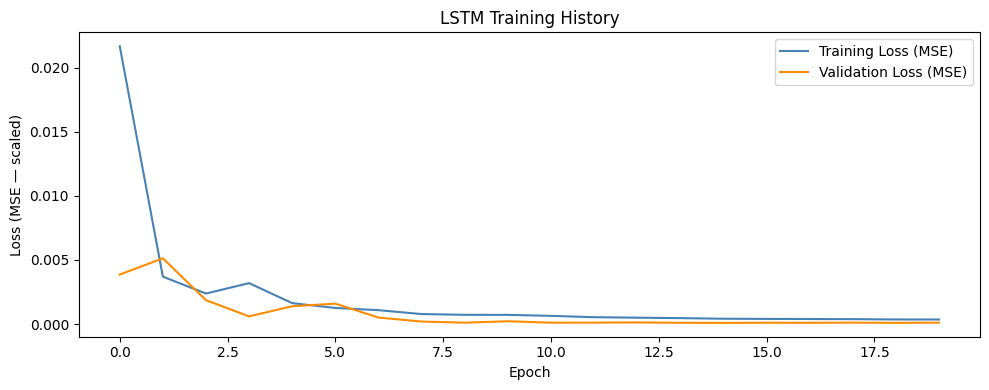

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Training Loss (MSE)',   color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='darkorange')
ax.set_title('LSTM Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE — scaled)')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluate LSTM: Reverse Scale and Compute Metrics
> ALWAYS reverse the scaler before computing MAE/RMSE. Metrics on scaled (0–1) values are meaningless.

In [3]:
y_pred_scaled = model.predict(X_test_lstm, verbose=0)

# Reverse scaling back to MW
y_pred_lstm = scaler.inverse_transform(y_pred_scaled).flatten()
y_true_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
r2_lstm   = r2_score(y_true_lstm, y_pred_lstm)

print('=== LSTM Results ===')
print(f'MAE :  {mae_lstm:.2f} MW')
print(f'RMSE:  {rmse_lstm:.2f} MW')
print(f'R²  :  {r2_lstm:.4f}')

NameError: name 'model' is not defined

Actual vs. Predicted Chart (LSTM)

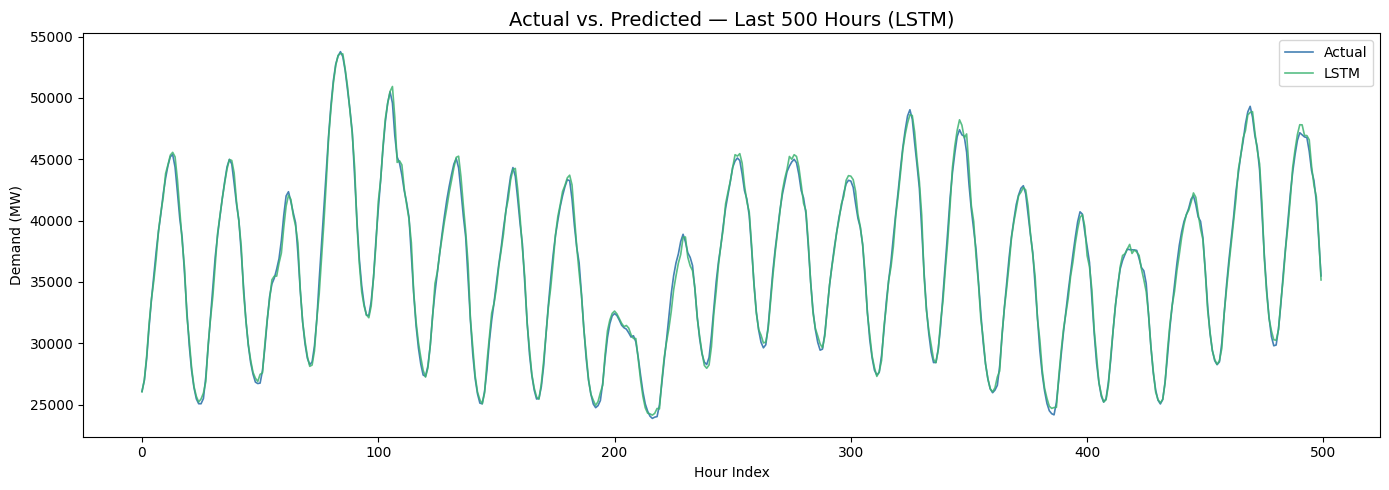

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_true_lstm[-500:], label='Actual', color='steelblue', linewidth=1.2)
ax.plot(y_pred_lstm[-500:], label='LSTM',   color='mediumseagreen', linewidth=1.2, alpha=0.85)
ax.set_title('Actual vs. Predicted — Last 500 Hours (LSTM)', fontsize=14)
ax.set_xlabel('Hour Index')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

Save LSTM Model and Scaler

In [2]:
LSTM_PATH   = '/content/drive/MyDrive/LoadForecasting/lstm_model.h5'
SCALER_PATH = '/content/drive/MyDrive/LoadForecasting/lstm_scaler.pkl'

model.save(LSTM_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f'LSTM saved to:   {LSTM_PATH}')
print(f'Scaler saved to: {SCALER_PATH}')

NameError: name 'model' is not defined

FINAL 4-Model Comparison Table
> This is the core result for your research paper. Fill in the baseline numbers from your Day 1 Cell 16 output.

In [1]:

mae_lr        = 4698.9596   # Linear Regression MAE
rmse_lr       = 3082.6502
r2_lr         = 0.2179

mae_xgb_base  = 354.77   # XGBoost Baseline
rmse_xgb_base = 469.87
r2_xgb_base   = 0.9947

mae_xgb_tuned  = 269.41   # XGBoost Tuned
rmse_xgb_tuned = 370.88
r2_xgb_tuned   = 0.9967


print('=' * 72)
print(f'{"Model":<35} {"MAE (MW)":>10} {"RMSE (MW)":>11} {"R² Score":>10}')
print('-' * 72)
print(f'{"Linear Regression (Baseline)":<35} {mae_lr:>10.1f} {rmse_lr:>11.1f} {r2_lr:>10.4f}')
print(f'{"XGBoost (Default)":<35} {mae_xgb_base:>10.1f} {rmse_xgb_base:>11.1f} {r2_xgb_base:>10.4f}')
print(f'{"XGBoost (Bayesian-Tuned, Optuna)":<35} {mae_xgb_tuned:>10.1f} {rmse_xgb_tuned:>11.1f} {r2_xgb_tuned:>10.4f}')
print(f'{"LSTM (2-Layer, 128-64 units)":<35} {mae_lstm:>10.1f} {rmse_lstm:>11.1f} {r2_lstm:>10.4f}')
print('=' * 72)
print()
print('Best model by R²:', max([
    ('Linear Regression', r2_lr),
    ('XGBoost Default', r2_xgb_base),
    ('XGBoost Tuned', r2_xgb_tuned),
    ('LSTM', r2_lstm)
], key=lambda x: x[1]))

Model                                 MAE (MW)   RMSE (MW)   R² Score
------------------------------------------------------------------------
Linear Regression (Baseline)            4699.0      3082.7     0.2179
XGBoost (Default)                        354.8       469.9     0.9947
XGBoost (Bayesian-Tuned, Optuna)         269.4       370.9     0.9967


NameError: name 'mae_lstm' is not defined